Using device: cpu
Dataset loaded successfully
Shape: (1000, 4)
   review_id           product  rating  \
0          1   Fitness Tracker       2   
1          2   Fitness Tracker       4   
2          3   Fitness Tracker       1   
3          4  Wireless Earbuds       5   
4          5   Smartphone Case       4   

                                  review_text  
0                   Exceeded my expectations!  
1                       Good value for money.  
2               Battery life could be better.  
3           Average product, expected better.  
4  Five stars, very happy with this purchase.  

Cleaned shape: (1000, 5)

Sentiment distribution:
sentiment
Negative    423
Positive    385
Neutral     192
Name: count, dtype: int64

Review type distribution:
review_type
Genuine    1000
Name: count, dtype: int64

Train size: 800
Test size: 200


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3
Train Loss: 1.0605
Val Loss:   1.0482
Val Acc:    0.4250
Val F1:     0.2535

Epoch 2/3
Train Loss: 1.0568
Val Loss:   1.0449
Val Acc:    0.4300
Val F1:     0.3186

Epoch 3/3
Train Loss: 1.0592
Val Loss:   1.0389
Val Acc:    0.4550
Val F1:     0.3613

Final Accuracy:
0.455

Final Weighted F1:
0.3612772585669781

Classification Report:
              precision    recall  f1-score   support

    Negative       0.45      0.89      0.60        85
     Neutral       0.00      0.00      0.00        38
    Positive       0.50      0.19      0.28        77

    accuracy                           0.46       200
   macro avg       0.32      0.36      0.29       200
weighted avg       0.38      0.46      0.36       200


Confusion Matrix:
[[76  0  9]
 [32  0  6]
 [62  0 15]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: saved_transformer_model


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Sample Prediction:
{'review': 'This product is amazing and worth the money.', 'cleaned_review': 'this product is amazing and worth the money.', 'predicted_sentiment': 'Negative', 'confidence_percent': 43.91, 'review_type': 'Genuine'}

Product-wise Sentiment Table:
sentiment            Negative  Neutral  Positive
product                                         
Bluetooth Speaker          37       19        48
Fitness Tracker            50       16        51
Gaming Mouse               42       28        55
LED Monitor                58       16        31
Laptop Stand               38       19        43
Mechanical Keyboard        44       18        33
Portable Charger           33       12        34
Smartphone Case            35       24        32
Smartwatch                 39       20        23
Wireless Earbuds           47       20        35


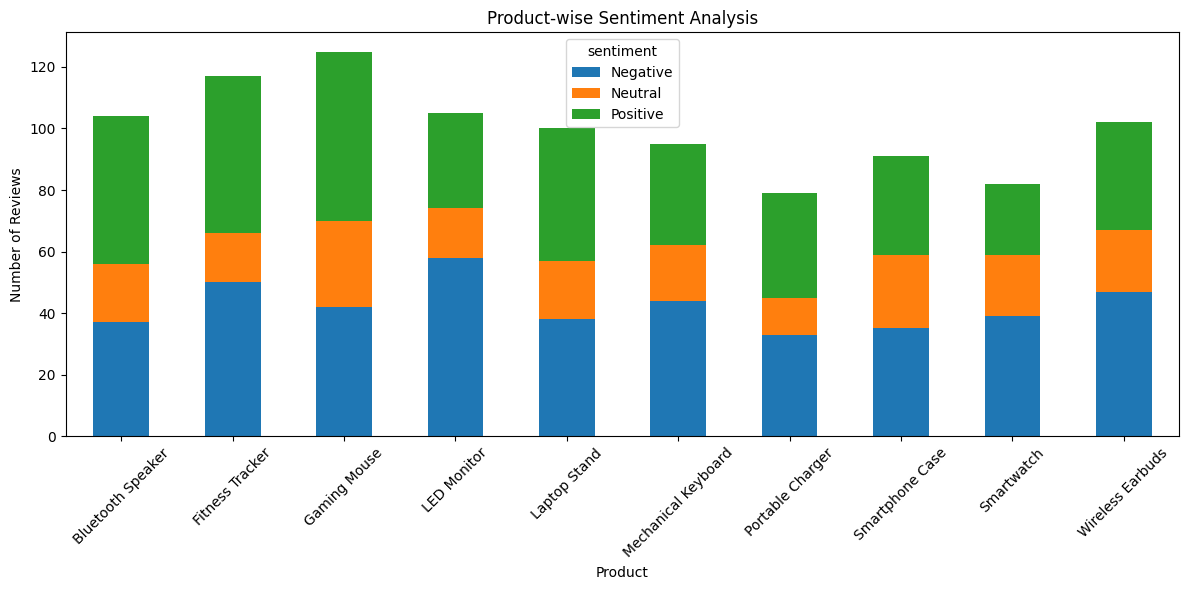

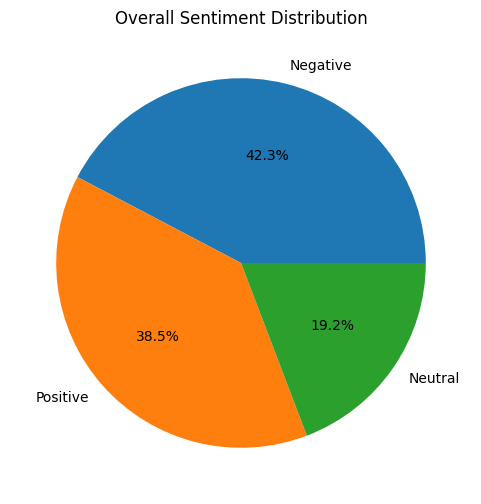

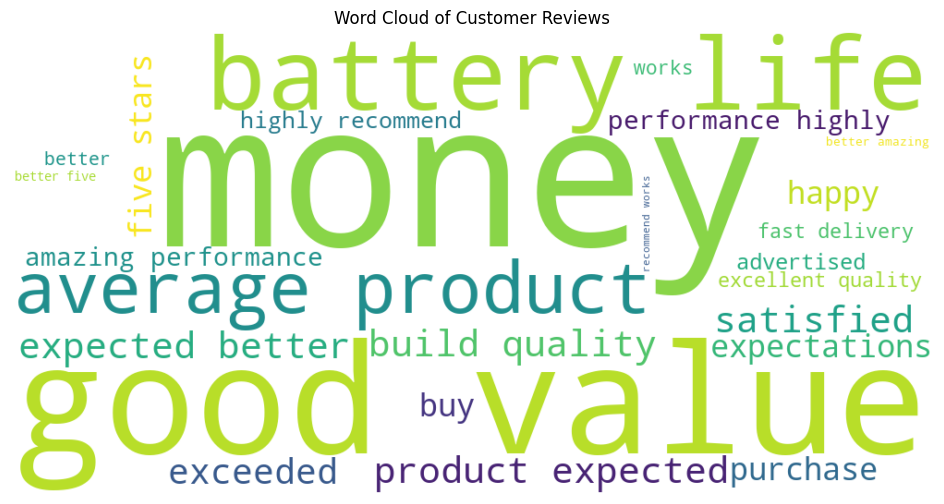


Top Products by Net Sentiment:
sentiment          Negative  Neutral  Positive  Net_Score
product                                                  
Gaming Mouse             42       28        55         13
Bluetooth Speaker        37       19        48         11
Laptop Stand             38       19        43          5
Fitness Tracker          50       16        51          1
Portable Charger         33       12        34          1

Worst Products by Net Sentiment:
sentiment            Negative  Neutral  Positive  Net_Score
product                                                    
LED Monitor                58       16        31        -27
Smartwatch                 39       20        23        -16
Wireless Earbuds           47       20        35        -12
Mechanical Keyboard        44       18        33        -11
Smartphone Case            35       24        32         -3

Summarization could not be completed.
Reason: "Unknown task summarization, available tasks are ['any-to-any

In [ ]:
# =========================================================
# TRANSFORMER-BASED E-COMMERCE / WALMART REVIEW ANALYSIS
# ALL-IN-ONE CODE
# NO datasets
# NO Trainer
# NO accelerate
# =========================================================

import os
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, pipeline
from wordcloud import WordCloud

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("ecommerce_reviews_1000.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
print(df.head())

# -------------------------
# CLEAN DATA
# -------------------------
selected_cols = [col for col in ['review_id', 'product', 'rating', 'review_text'] if col in df.columns]
df = df[selected_cols].copy()

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df["review_text"] = df["review_text"].astype(str).str.strip()

if "product" not in df.columns:
    df["product"] = "Unknown Product"

df = df[df["review_text"] != ""]

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s!?.,']", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review_text"].apply(clean_text)

print("\nCleaned shape:", df.shape)

# -------------------------
# SENTIMENT LABELS
# -------------------------
def rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}

df["label"] = df["sentiment"].map(label2id)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

# -------------------------
# FAKE REVIEW DETECTION
# -------------------------
def detect_fake(review):
    words = review.split()
    if len(words) < 3:
        return "Fake"
    if review.count("!!!") >= 2:
        return "Fake"
    if len(set(words)) <= 2 and len(words) > 0:
        return "Fake"
    return "Genuine"

df["review_type"] = df["clean_review"].apply(detect_fake)

print("\nReview type distribution:")
print(df["review_type"].value_counts())

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_review"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("\nTrain size:", len(train_texts))
print("Test size:", len(test_texts))

# -------------------------
# TOKENIZER
# -------------------------
MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# -------------------------
# CUSTOM DATASET
# -------------------------
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# -------------------------
# MODEL
# -------------------------
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.to(device)

# -------------------------
# OPTIMIZER
# -------------------------
optimizer = AdamW(model.parameters(), lr=2e-5)

# -------------------------
# TRAINING LOOP
# -------------------------
epochs = 3

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    val_preds = []
    val_true = []
    total_val_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(test_loader)
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="weighted")

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")
    print(f"Val F1:     {val_f1:.4f}")

# -------------------------
# FINAL EVALUATION
# -------------------------
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

print("\nFinal Accuracy:")
print(accuracy_score(all_true, all_preds))

print("\nFinal Weighted F1:")
print(f1_score(all_true, all_preds, average="weighted"))

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=["Negative", "Neutral", "Positive"]))

print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_preds))

# -------------------------
# SAVE MODEL
# -------------------------
SAVE_DIR = "saved_transformer_model"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"\nModel saved to: {SAVE_DIR}")

# -------------------------
# LOAD MODEL FOR PREDICTION
# -------------------------
loaded_tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
loaded_model = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
loaded_model.to(device)
loaded_model.eval()

# -------------------------
# PREDICTION FUNCTION
# -------------------------
def predict_review(text):
    clean = clean_text(text)

    inputs = loaded_tokenizer(
        clean,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_class].item()

    return {
        "review": text,
        "cleaned_review": clean,
        "predicted_sentiment": id2label[pred_class],
        "confidence_percent": round(confidence * 100, 2),
        "review_type": detect_fake(clean)
    }

# -------------------------
# SAMPLE PREDICTION
# -------------------------
print("\nSample Prediction:")
print(predict_review("This product is amazing and worth the money."))

# -------------------------
# PRODUCT-WISE SENTIMENT ANALYSIS
# -------------------------
product_sentiment = df.groupby(["product", "sentiment"]).size().unstack().fillna(0)

print("\nProduct-wise Sentiment Table:")
print(product_sentiment)

product_sentiment.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Product-wise Sentiment Analysis")
plt.xlabel("Product")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------
# OVERALL SENTIMENT PIE CHART
# -------------------------
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%")
plt.title("Overall Sentiment Distribution")
plt.show()

# -------------------------
# WORD CLOUD
# -------------------------
all_text = " ".join(df["clean_review"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")
plt.show()

# -------------------------
# TOP / WORST PRODUCTS
# -------------------------
sentiment_summary = df.groupby(["product", "sentiment"]).size().unstack(fill_value=0)

if "Positive" not in sentiment_summary.columns:
    sentiment_summary["Positive"] = 0
if "Negative" not in sentiment_summary.columns:
    sentiment_summary["Negative"] = 0

sentiment_summary["Net_Score"] = sentiment_summary["Positive"] - sentiment_summary["Negative"]

print("\nTop Products by Net Sentiment:")
print(sentiment_summary.sort_values(by="Net_Score", ascending=False).head())

print("\nWorst Products by Net Sentiment:")
print(sentiment_summary.sort_values(by="Net_Score", ascending=True).head())

# -------------------------
# REVIEW SUMMARIZATION
# -------------------------
try:
    summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")

    long_text = " ".join(df["review_text"].head(25).tolist())
    long_text = long_text[:1000]

    summary = summarizer(long_text, max_length=80, min_length=25, do_sample=False)

    print("\nGenerated Summary:")
    print(summary[0]["summary_text"])

except Exception as e:
    print("\nSummarization could not be completed.")
    print("Reason:", e)

# -------------------------
# SAVE CLEANED DATA
# -------------------------
df.to_csv("processed_ecommerce_reviews.csv", index=False)
print("\nProcessed dataset saved as processed_ecommerce_reviews.csv")

# -------------------------
# BATCH TEST PREDICTIONS
# -------------------------
test_reviews = [
    "Excellent product, I am very satisfied.",
    "It is okay, not bad but not great.",
    "Very poor quality and complete waste of money.",
    "Nice",
    "Worst purchase ever!!! !!!"
]

print("\nBatch Predictions:")
results = []
for review in test_reviews:
    result = predict_review(review)
    print(result)
    results.append(result)

pd.DataFrame(results).to_csv("sample_predictions.csv", index=False)
print("\nSample predictions saved as sample_predictions.csv")

print("\nProject completed successfully.")